# Lab 4 — LUNA16 Evaluation
**Evaluation only** — loads pre-trained `best_model.pth` and generates all metrics + figures.

In [1]:
import os, gc, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

torch.cuda.empty_cache(); gc.collect()

BASE = '/kaggle/input/datasets/avc0706/luna16'
ANNOTATIONS_CSV   = os.path.join(BASE, 'annotations.csv')
CANDIDATES_V2_CSV = os.path.join(BASE, 'candidates_V2', 'candidates_V2.csv')
# Path to pre-trained model (add as Kaggle input)
MODEL_PATH = '/kaggle/input/models/migurdiaroxy/model-lab4/other/default/1/best_model.pth'
FIG_DIR = '/kaggle/working/figures'
os.makedirs(FIG_DIR, exist_ok=True)

PATCH_SIZE = 32
BATCH_SIZE = 32
NUM_WORKERS = 2
NEG_RATIO = 20

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla P100-PCIE-16GB


## 1. Load Dataset & Extract Val Patches

In [2]:
# Build scan mapping
available_scans = {}
for mhd in glob.glob(os.path.join(BASE, 'subset*', '**', '*.mhd'), recursive=True):
    uid = os.path.basename(mhd).replace('.mhd', '')
    available_scans[uid] = mhd
print(f'CT scans found: {len(available_scans)}')

annotations = pd.read_csv(ANNOTATIONS_CSV)
candidates  = pd.read_csv(CANDIDATES_V2_CSV)
annotations['seriesuid'] = annotations['seriesuid'].str.strip()
candidates['seriesuid']  = candidates['seriesuid'].str.strip()

avail_uids = set(available_scans.keys())
cand = candidates[candidates.seriesuid.isin(avail_uids)].copy()
n_pos = int((cand['class']==1).sum())
n_neg = int((cand['class']==0).sum())
print(f'Candidates: {len(cand):,} (pos={n_pos:,}, neg={n_neg:,})')

# Subsample negatives
n_neg_keep = min(NEG_RATIO * n_pos, n_neg)
pos_cand = cand[cand['class'] == 1]
neg_cand = cand[cand['class'] == 0].sample(n=n_neg_keep, random_state=42)
cand_sub = pd.concat([pos_cand, neg_cand]).reset_index(drop=True)
print(f'After subsampling: {len(cand_sub):,} (pos={len(pos_cand):,}, neg={len(neg_cand):,})')

# Assign subsets
uid_to_subset = {}
for mhd_path in available_scans.values():
    for p in mhd_path.split('/'):
        if p.startswith('subset'):
            uid = os.path.basename(mhd_path).replace('.mhd', '')
            uid_to_subset[uid] = int(p.replace('subset', ''))
            break
cand_sub['subset'] = cand_sub['seriesuid'].map(uid_to_subset)


CT scans found: 445
Candidates: 377,138 (pos=817, neg=376,321)
After subsampling: 17,157 (pos=817, neg=16,340)


In [3]:
def load_ct_scan(mhd_path):
    itk_img = sitk.ReadImage(mhd_path)
    ct = sitk.GetArrayFromImage(itk_img)
    origin = np.array(itk_img.GetOrigin())
    spacing = np.array(itk_img.GetSpacing())
    direction = np.array(itk_img.GetDirection()).reshape(3, 3)
    return ct, origin, spacing, direction

def world_to_voxel(world_coord, origin, spacing, direction):
    stretched = np.abs(direction) @ np.diag(spacing)
    voxel = np.linalg.solve(stretched, world_coord - origin)
    return np.round(voxel).astype(int)[::-1]

def normalize_hu(ct, hu_min=-1000, hu_max=400):
    ct = np.clip(ct, hu_min, hu_max)
    return ((ct - hu_min) / (hu_max - hu_min)).astype(np.float32)

def extract_patch(ct, center_zyx, size=32):
    h = size // 2
    D, H, W = ct.shape
    z, y, x = int(center_zyx[0]), int(center_zyx[1]), int(center_zyx[2])
    z = max(0, min(z, D - 1))
    y = max(0, min(y, H - 1))
    x = max(0, min(x, W - 1))
    z0, z1 = max(z-h, 0), min(z+h, D)
    y0, y1 = max(y-h, 0), min(y+h, H)
    x0, x1 = max(x-h, 0), min(x+h, W)
    pz0 = h-(z-z0); pz1 = pz0+(z1-z0)
    py0 = h-(y-y0); py1 = py0+(y1-y0)
    px0 = h-(x-x0); px1 = px0+(x1-x0)
    patch = np.zeros((size, size, size), dtype=np.float32)
    patch[pz0:pz1, py0:py1, px0:px1] = ct[z0:z1, y0:y1, x0:x1]
    return patch

print('Helpers defined!')


Helpers defined!


In [4]:
# Extract ONLY validation patches (subset 4) to save memory
val_cand = cand_sub[cand_sub['subset'] == 4]
print(f'Val candidates: {len(val_cand):,} (pos={int((val_cand["class"]==1).sum()):,}, neg={int((val_cand["class"]==0).sum()):,})')

patches_list, labels_list, scan_ids = [], [], []
skipped = 0
unique_uids = val_cand['seriesuid'].unique()
print(f'Processing {len(unique_uids)} val scans...')

for i, uid in enumerate(unique_uids):
    if uid not in available_scans:
        continue
    try:
        ct, origin, spacing, direction = load_ct_scan(available_scans[uid])
        ct_norm = normalize_hu(ct)
    except Exception as e:
        print(f'  Skip {uid[:20]}... ({e})')
        continue
    D, H, W = ct_norm.shape
    scan_cands = val_cand[val_cand.seriesuid == uid]
    for _, row in scan_cands.iterrows():
        world = np.array([row.coordX, row.coordY, row.coordZ])
        voxel = world_to_voxel(world, origin, spacing, direction)
        vz, vy, vx = int(voxel[0]), int(voxel[1]), int(voxel[2])
        if vz < -PATCH_SIZE or vz >= D+PATCH_SIZE or \
           vy < -PATCH_SIZE or vy >= H+PATCH_SIZE or \
           vx < -PATCH_SIZE or vx >= W+PATCH_SIZE:
            skipped += 1
            continue
        patch = extract_patch(ct_norm, voxel, PATCH_SIZE)
        patches_list.append(patch)
        labels_list.append(int(row['class']))
        scan_ids.append(uid)
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(unique_uids)} scans, {len(patches_list):,} patches')
    del ct, ct_norm; gc.collect()

val_patches = np.array(patches_list, dtype=np.float32)
val_labels  = np.array(labels_list, dtype=np.int64)
val_scans   = np.array(scan_ids)
print(f'\nVal patches: {len(val_patches):,} (skipped: {skipped})')
print(f'  Positive: {(val_labels==1).sum():,}, Negative: {(val_labels==0).sum():,}')
print(f'  Memory: {val_patches.nbytes / 1e9:.2f} GB')
del patches_list, labels_list; gc.collect()


Val candidates: 3,523 (pos=170, neg=3,353)
Processing 89 val scans...
  20/89 scans, 883 patches
  40/89 scans, 1,773 patches
  60/89 scans, 2,671 patches
  80/89 scans, 3,331 patches

Val patches: 3,505 (skipped: 18)
  Positive: 169, Negative: 3,336
  Memory: 0.46 GB


0

## 2. Load Model

In [5]:
class NoduleClassifier3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 64, 3, padding=1, bias=False), nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.Conv3d(64, 64, 3, padding=1, bias=False), nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),
            nn.Conv3d(64, 128, 3, padding=1, bias=False), nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.Conv3d(128, 128, 3, padding=1, bias=False), nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),
            nn.Conv3d(128, 256, 3, padding=1, bias=False), nn.BatchNorm3d(256), nn.ReLU(inplace=True),
            nn.Conv3d(256, 256, 3, padding=1, bias=False), nn.BatchNorm3d(256), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),
            nn.Conv3d(256, 512, 3, padding=1, bias=False), nn.BatchNorm3d(512), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 64),  nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(-1)

model = NoduleClassifier3D().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model params: {n_params:,}')

# Load pre-trained weights
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded best_model.pth (epoch {ckpt['epoch']+1}, val_auc={ckpt['val_auc']:.4f})")


Model params: 7,045,825
Loaded best_model.pth (epoch 15, val_auc=0.9978)


## 3. Run Inference

In [6]:
class ValDataset(Dataset):
    def __init__(self, patches, labels):
        self.patches = patches
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.patches[idx]).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

val_ds = ValDataset(val_patches, val_labels)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

all_probs, all_labels_list = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(val_loader, desc='Inference'):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels_list.extend(lbls.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels_list)
print(f'Predictions: {len(all_probs):,}')


Inference: 100%|██████████| 110/110 [00:14<00:00,  7.35it/s]

Predictions: 3,505


## 4. Metrics

In [7]:
auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Optimal threshold via Youden's J
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
preds = (all_probs >= opt_thresh).astype(int)
sens = (preds[all_labels==1] == 1).mean()
spec = (preds[all_labels==0] == 0).mean()
f1 = f1_score(all_labels, preds)

print(f'AUC-ROC:     {auc:.4f}')
print(f'Threshold:   {opt_thresh:.4f}')
print(f'Sensitivity: {sens:.4f}')
print(f'Specificity: {spec:.4f}')
print(f'F1-Score:    {f1:.4f}')


AUC-ROC:     0.9978
Threshold:   0.3162
Sensitivity: 0.9941
Specificity: 0.9616
F1-Score:    0.7226


## 5. FROC & CPM

In [8]:
def compute_froc(val_probs, val_labels, val_scan_ids):
    n_pos = int((val_labels == 1).sum())
    n_scans = len(np.unique(val_scan_ids))
    thresholds = np.linspace(0, 1, 2000)
    sens_list, fps_list = [], []
    for t in thresholds:
        above = val_probs >= t
        tp = int(((above) & (val_labels == 1)).sum())
        fp = int(((above) & (val_labels == 0)).sum())
        sens_list.append(tp / max(n_pos, 1))
        fps_list.append(fp / max(n_scans, 1))
    return np.array(fps_list), np.array(sens_list)

def compute_cpm(fp_per_scan, sensitivities):
    ops = [0.125, 0.25, 0.5, 1, 2, 4, 8]
    vals = []
    for fp_rate in ops:
        idx = np.searchsorted(fp_per_scan, fp_rate)
        if idx == 0:
            s = sensitivities[0]
        elif idx >= len(fp_per_scan):
            s = sensitivities[-1]
        else:
            x0, x1 = fp_per_scan[idx-1], fp_per_scan[idx]
            y0, y1 = sensitivities[idx-1], sensitivities[idx]
            s = y0 + (y1 - y0) * (fp_rate - x0) / (x1 - x0 + 1e-10)
        vals.append(s)
    return np.mean(vals), ops, vals

fp_rate, sensitivity = compute_froc(all_probs, all_labels, val_scans)
cpm_score, op_points, cpm_vals = compute_cpm(fp_rate, sensitivity)

print(f'CPM Score: {cpm_score:.4f}')
print(f'\nSensitivity at operating points:')
for op, val in zip(op_points, cpm_vals):
    print(f'  {op:5.3f} FP/scan -> {val:.4f}')


CPM Score: 0.4286

Sensitivity at operating points:
  0.125 FP/scan -> 1.0000
  0.250 FP/scan -> 1.0000
  0.500 FP/scan -> 1.0000
  1.000 FP/scan -> 0.0000
  2.000 FP/scan -> 0.0000
  4.000 FP/scan -> 0.0000
  8.000 FP/scan -> 0.0000


## 6. Figures

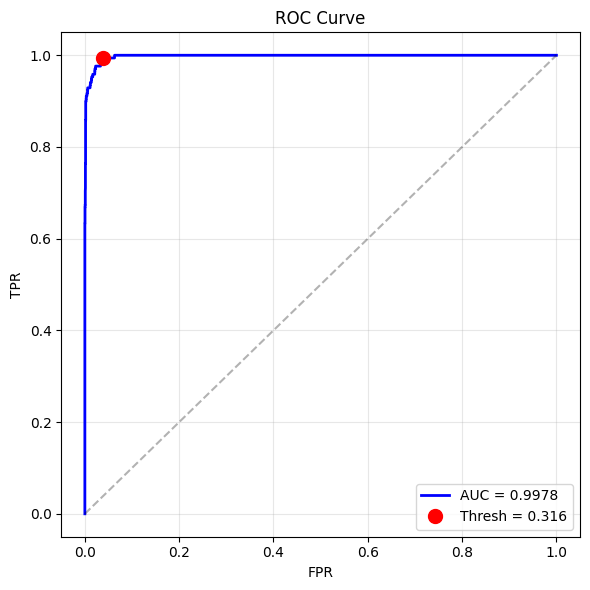

In [9]:
# Fig 1: ROC
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.4f}')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.plot(fpr[opt_idx], tpr[opt_idx], 'ro', ms=10, label=f'Thresh = {opt_thresh:.3f}')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curve.pdf'), dpi=300, bbox_inches='tight')
plt.show()


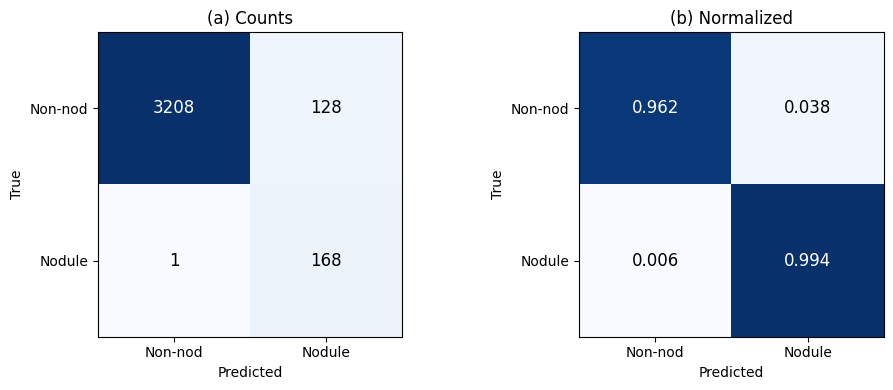

In [10]:
# Fig 2: Confusion matrix
cm = confusion_matrix(all_labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in [(ax1, cm, '(a) Counts'), (ax2, cm_norm, '(b) Normalized')]:
    ax.imshow(data, cmap='Blues', interpolation='nearest')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Non-nod', 'Nodule']); ax.set_yticklabels(['Non-nod', 'Nodule'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            v = data[i, j]
            txt = f'{int(v):d}' if isinstance(v, (int, np.integer)) else f'{v:.3f}'
            ax.text(j, i, txt, ha='center', va='center',
                    color='white' if v > data.max()/2 else 'black', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.pdf'), dpi=300, bbox_inches='tight')
plt.show()


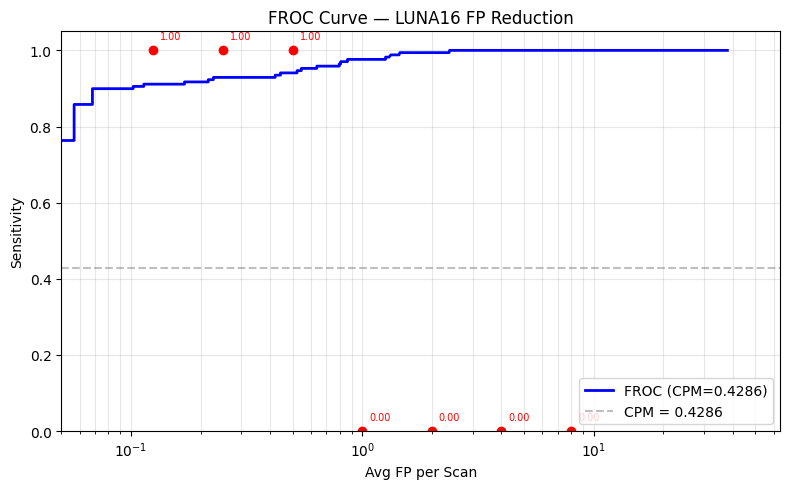

In [11]:
# Fig 3: FROC curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fp_rate, sensitivity, 'b-', lw=2, label=f'FROC (CPM={cpm_score:.4f})')
for op, val in zip(op_points, cpm_vals):
    ax.plot(op, val, 'ro', ms=6)
    ax.annotate(f'{val:.2f}', (op, val), textcoords='offset points',
                xytext=(5, 8), fontsize=7, color='red')
ax.axhline(cpm_score, ls='--', color='gray', alpha=0.5, label=f'CPM = {cpm_score:.4f}')
ax.set_xlabel('Avg FP per Scan'); ax.set_ylabel('Sensitivity')
ax.set_title('FROC Curve — LUNA16 FP Reduction')
ax.set_xscale('log'); ax.set_xlim(0.05, 64); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'froc_curve.pdf'), dpi=300, bbox_inches='tight')
plt.show()


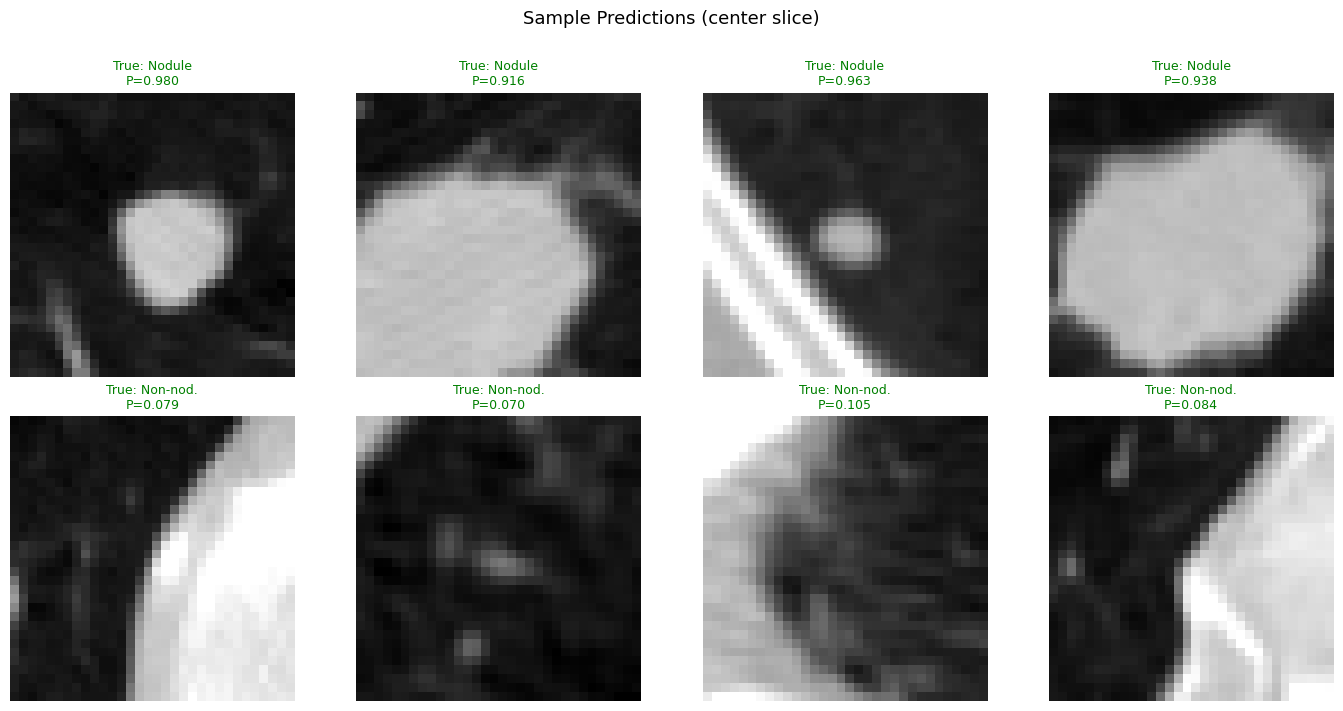

In [12]:
# Fig 4: Sample predictions
pos_idx = np.where(all_labels == 1)[0]
neg_idx = np.where(all_labels == 0)[0]
np.random.seed(42)
show_pos = np.random.choice(pos_idx, min(4, len(pos_idx)), replace=False)
show_neg = np.random.choice(neg_idx, min(4, len(neg_idx)), replace=False)
show_idx = np.concatenate([show_pos, show_neg])
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, idx in enumerate(show_idx):
    r, c = j // 4, j % 4
    patch = val_patches[idx]
    axes[r, c].imshow(patch[patch.shape[0]//2], cmap='gray', vmin=0, vmax=1)
    lbl = 'Nodule' if all_labels[idx] == 1 else 'Non-nod.'
    prob = all_probs[idx]
    clr = 'green' if (all_labels[idx]==1) == (prob >= opt_thresh) else 'red'
    axes[r, c].set_title(f'True: {lbl}\nP={prob:.3f}', fontsize=9, color=clr)
    axes[r, c].axis('off')
axes[0,0].set_ylabel('Positive', fontsize=11, fontweight='bold', color='green')
axes[1,0].set_ylabel('Negative', fontsize=11, fontweight='bold', color='red')
fig.suptitle('Sample Predictions (center slice)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sample_predictions.pdf'), dpi=300, bbox_inches='tight')
plt.show()


## 7. Summary

In [13]:
print('=' * 60)
print('Evaluation Summary')
print('=' * 60)
print(f'Model:       NoduleClassifier3D ({n_params:,} params)')
print(f'Val patches: {len(val_patches):,}')
print(f'AUC-ROC:     {auc:.4f}')
print(f'Sensitivity: {sens:.4f}')
print(f'Specificity: {spec:.4f}')
print(f'F1-Score:    {f1:.4f}')
print(f'CPM Score:   {cpm_score:.4f}')
print()
print('Figures saved:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {f}')


Evaluation Summary
Model:       NoduleClassifier3D (7,045,825 params)
Val patches: 3,505
AUC-ROC:     0.9978
Sensitivity: 0.9941
Specificity: 0.9616
F1-Score:    0.7226
CPM Score:   0.4286

Figures saved:
  confusion_matrix.pdf
  froc_curve.pdf
  roc_curve.pdf
  sample_predictions.pdf
